# 02 — Supply Resilience Walkthrough

**Module:** `msmt.resilience` &nbsp;•&nbsp; **Companion to:** *Main Street Marketplace*, Article 2 — *Stop Running Out of Stock*.

This notebook walks an SBDC counselor (or a small marketplace seller who's comfortable in Python) through the toolkit's full supply-resilience pipeline using synthetic seller data. Nothing here requires real seller exports — the same code runs on a real catalog by replacing the synthetic DataFrame with the seller's own.

The pipeline answers four practical questions, in order:

1. **What kind of demand pattern does each SKU have?** (smooth, weekly, holiday-spiky, lumpy, brand-new)
2. **How much safety stock is appropriate for that pattern?**
3. **At what on-hand level should the seller reorder?**
4. **Which SKUs are most at risk of stocking out right now?**

We close with a worked example of the *true* cost of a stockout — the lost-sales number a seller can see in their portal *plus* the harder-to-see ranking-tail cost.

> **Note on the data.** Everything generated below is **synthetic**. It does not come from any real seller's data. The synthetic generator is designed to look and feel like a marketplace seller-portal export so the code runs end-to-end.


## 1. Generate the practice dataset

We'll generate 50 SKUs with a year of daily history. The generator mixes all five demand patterns, so the rest of the notebook gets a realistic spread of SKUs to work with.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from msmt.data import generate_seller_data

seller_df = generate_seller_data(n_skus=50, n_days=365, seed=42)
print(f"rows: {len(seller_df):,}  |  unique SKUs: "
      f"{seller_df['sku_id'].nunique()}  |  date range: "
      f"{seller_df['date'].min().date()} \u2192 "
      f"{seller_df['date'].max().date()}")
seller_df.head()


Matplotlib is building the font cache; this may take a moment.


rows: 18,250  |  unique SKUs: 50  |  date range: 2025-01-01 → 2025-12-31


,date,sku_id,units_sold,listing_price,stock_on_hand,lead_time_days,category,pattern
0,2025-01-01,SKU-HS-0032,7,20.08,272,37,Arts & Crafts,holiday_spike
1,2025-01-02,SKU-HS-0032,9,20.08,263,37,Arts & Crafts,holiday_spike
2,2025-01-03,SKU-HS-0032,8,20.08,255,37,Arts & Crafts,holiday_spike
3,2025-01-04,SKU-HS-0032,10,20.08,245,37,Arts & Crafts,holiday_spike
4,2025-01-05,SKU-HS-0032,11,20.08,234,37,Arts & Crafts,holiday_spike


Each SKU carries the demand pattern it was generated from in the `pattern` column. We'll use that as ground truth in the next step to check how well the classifier recovers it. **In real use you won't have this column** — that's the whole point of the classifier.

## 2. Classify each SKU's demand pattern

The classifier walks through a five-step decision tree:

1. *Too new?* fewer than 8 weeks of active history → **new SKU**
2. *Too lumpy?* more than 40% zero-sale days → **intermittent**
3. *Weekly rhythm?* day-of-week swing above 15% → **weekly seasonal**
4. *Big rare bursts?* a 14-day rolling mean that peaks above 2.5× the median → **holiday spike**
5. Otherwise → **smooth**

Each call returns the chosen pattern *and* a confidence in [0, 1] — how cleanly the rule fired.

In [2]:
from msmt.resilience import classify_pattern

rows = []
for sku_id, sub in seller_df.groupby('sku_id', sort=False):
    truth = sub['pattern'].iloc[0]
    pred, conf = classify_pattern(sub)
    rows.append({
        'sku_id': sku_id,
        'true_pattern': truth,
        'predicted_pattern': pred,
        'confidence': round(conf, 3),
        'correct': pred == truth,
    })
classified = pd.DataFrame(rows)
accuracy = classified['correct'].mean()
print(f"Classifier accuracy on synthetic ground truth: {accuracy:.0%}")
classified.head(10)


Classifier accuracy on synthetic ground truth: 92%


,sku_id,true_pattern,predicted_pattern,confidence,correct
0,SKU-HS-0032,holiday_spike,smooth,0.172,False
1,SKU-HS-0033,holiday_spike,holiday_spike,0.487,True
2,SKU-HS-0034,holiday_spike,smooth,0.212,False
3,SKU-HS-0035,holiday_spike,holiday_spike,0.409,True
4,SKU-HS-0036,holiday_spike,smooth,0.057,False
5,SKU-HS-0037,holiday_spike,smooth,0.117,False
6,SKU-HS-0038,holiday_spike,holiday_spike,0.284,True
7,SKU-IM-0039,intermittent,intermittent,1.000,True
8,SKU-IM-0040,intermittent,intermittent,1.000,True
9,SKU-IM-0041,intermittent,intermittent,1.000,True


In [3]:
# Per-pattern breakdown — useful when explaining where the rules
# disagree with the synthetic labels.
by_pattern = classified.groupby('true_pattern')['correct'].agg(
    correct='sum', total='count'
).assign(rate=lambda d: (d['correct'] / d['total']).map(lambda x: f'{x:.0%}'))
by_pattern


,correct,total,rate
true_pattern,,,
holiday_spike,3,7,43%
intermittent,7,7,100%
new_sku,5,5,100%
smooth,18,18,100%
weekly_seasonal,13,13,100%


**Reading this table.** A counselor can use this to show a seller *why* their SKU was put into a particular bucket. A low confidence (say, below 0.3) is the cue to look at the underlying chart manually before trusting the recommendation.

## 3. Compute safety stock and reorder points

Different demand patterns deserve different safety-stock math:

| Pattern | Method | Why |
|---|---|---|
| smooth, weekly seasonal | textbook normal | bell-curve assumption holds |
| holiday spike | percentile of bootstrapped lead-time demand | fat tails, normal under-buffers |
| intermittent | simplified Croston-inspired | size and incidence vary independently |
| new SKU | textbook normal, with a caveat | history is too short to trust deeply either way |

`reorder_point_for_sku` does the dispatch automatically and returns the reorder point, the safety stock, and which method was used. We run it across the catalog at a 95% service level.

In [4]:
from msmt.resilience import reorder_point_for_sku

service_level = 0.95
rop_rows = []
for sku_id, sub in seller_df.groupby('sku_id', sort=False):
    info = reorder_point_for_sku(sub, service_level=service_level)
    rop_rows.append({'sku_id': sku_id, **info})
rop_df = pd.DataFrame(rop_rows).round(2)
rop_df.head(10)


,sku_id,rop,safety_stock,method_used,pattern,demand_mean,lead_time_mean
0,SKU-HS-0032,373.55,56.26,normal,smooth,8.58,37.0
1,SKU-HS-0033,590.49,242.00,kde,holiday_spike,8.71,40.0
2,SKU-HS-0034,97.49,29.28,normal,smooth,9.75,7.0
3,SKU-HS-0035,546.88,207.10,kde,holiday_spike,8.71,39.0
4,SKU-HS-0036,334.50,59.32,normal,smooth,9.17,30.0
5,SKU-HS-0037,184.11,46.36,normal,smooth,9.18,15.0
6,SKU-HS-0038,398.90,195.00,kde,holiday_spike,9.71,21.0
7,SKU-IM-0039,215.85,196.95,intermittent,intermittent,0.76,25.0
8,SKU-IM-0040,221.63,199.36,intermittent,intermittent,0.74,30.0
9,SKU-IM-0041,278.51,257.70,intermittent,intermittent,0.58,36.0


## 4. Score current stockout risk across the catalog

`stockout_heatmap_data` chains everything together: classify → safety stock → reorder point → risk score. The result is one row per SKU, ranked from most-at-risk to least.

In [5]:
from msmt.resilience import stockout_heatmap_data

heatmap = stockout_heatmap_data(seller_df, service_level=service_level)
print(f"SKUs analyzed: {len(heatmap)}")
heatmap.head(10).round(2)


SKUs analyzed: 50


,sku_id,pattern,method_used,rop,safety_stock,current_stock,risk_score,risk_level,days_until_stockout,action
0,SKU-IM-0043,intermittent,intermittent,109.44,98.12,19.0,1.00,critical,21.81,Place an emergency reorder today and consider ...
1,SKU-IM-0045,intermittent,intermittent,77.67,71.43,7.0,1.00,critical,14.00,Place an emergency reorder today and consider ...
2,SKU-NS-0048,new_sku,normal,19.96,12.75,4.0,1.00,critical,0.63,Place an emergency reorder today and consider ...
3,SKU-IM-0041,intermittent,intermittent,278.51,257.70,59.0,0.99,critical,103.25,Place an emergency reorder today and consider ...
4,SKU-IM-0039,intermittent,intermittent,215.85,196.95,46.0,0.98,critical,117.09,Place an emergency reorder today and consider ...
5,SKU-IM-0042,intermittent,intermittent,256.07,237.72,67.0,0.92,critical,144.31,Place an emergency reorder today and consider ...
6,SKU-IM-0040,intermittent,intermittent,221.63,199.36,61.0,0.91,critical,58.90,Place an emergency reorder today and consider ...
7,SKU-HS-0034,smooth,normal,97.49,29.28,42.0,0.71,high,3.38,Reorder this week — at the current sell-throug...
8,SKU-WS-0022,weekly_seasonal,normal,455.12,78.23,292.0,0.45,medium,18.25,Schedule a reorder in the next two weeks and r...
9,SKU-SM-0015,smooth,normal,180.76,35.36,124.0,0.39,medium,12.67,Schedule a reorder in the next two weeks and r...


In [6]:
# Distribution across the four risk levels
heatmap['risk_level'].value_counts().reindex(
    ['critical', 'high', 'medium', 'low']
).fillna(0).astype(int)


risk_level
critical     7
high         1
medium       3
low         39
Name: count, dtype: int64

## 5. Visualize the catalog risk picture

Two charts that go in front of a seller or a counselor: a count of SKUs by risk level, and a scatter of current on-hand stock against each SKU's computed reorder point.

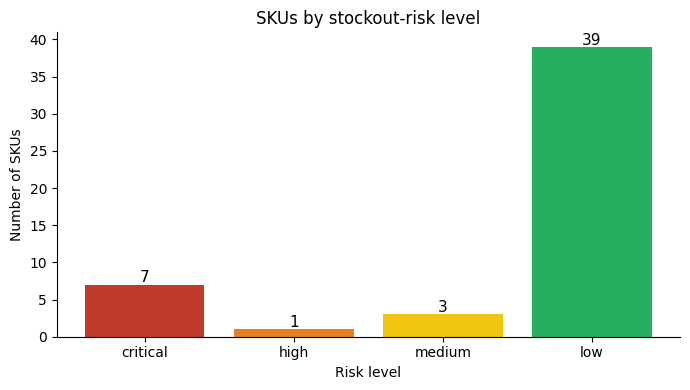

In [7]:
plt.style.use('default')
level_order = ['critical', 'high', 'medium', 'low']
level_colors = {
    'critical': '#c0392b',
    'high':     '#e67e22',
    'medium':   '#f1c40f',
    'low':      '#27ae60',
}

counts = heatmap['risk_level'].value_counts().reindex(level_order).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(counts.index, counts.values, color=[level_colors[l] for l in counts.index])
ax.set_title('SKUs by stockout-risk level')
ax.set_xlabel('Risk level')
ax.set_ylabel('Number of SKUs')
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.3, str(v), ha='center', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


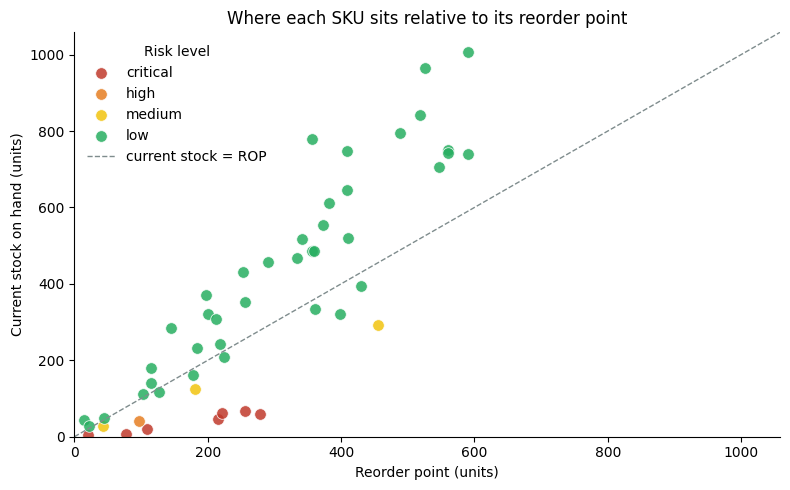

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
for level in level_order:
    sub = heatmap[heatmap['risk_level'] == level]
    if sub.empty:
        continue
    ax.scatter(
        sub['rop'],
        sub['current_stock'],
        s=70, alpha=0.85, edgecolors='white', linewidth=0.6,
        color=level_colors[level], label=level,
    )
lim = max(heatmap['rop'].max(), heatmap['current_stock'].max()) * 1.05
ax.plot([0, lim], [0, lim], color='#7f8c8d', linestyle='--', linewidth=1,
        label='current stock = ROP')
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel('Reorder point (units)')
ax.set_ylabel('Current stock on hand (units)')
ax.set_title('Where each SKU sits relative to its reorder point')
ax.legend(title='Risk level', loc='upper left', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


**How to read the scatter.** Any SKU below the dashed line is sitting with less stock than its reorder point — i.e. the seller should have already placed an order. The further below the line a SKU sits, the more urgent the situation.

## 6. The true cost of a stockout

When a marketplace listing goes out of stock, the lost margin during the outage is only part of the cost. Marketplace ranking and recommendation algorithms tend to demote listings that go unavailable, and most listings take some weeks to climb back to where they were once they're restocked. Most small sellers underestimate this *suppression tail* because the direct lost-sale number is the only one their seller portal shows.

`suppression_adjusted_stockout_cost` lets a seller put a defensible (if rough) figure on that tail.

> **Important caveat.** The default 3.0× suppression multiplier and 21-day recovery window are **practitioner estimates derived from industry observation of how marketplace listings tend to behave after stockouts**. They are *not* figures disclosed, confirmed, or published by any marketplace platform. A seller with their own historical stockout/recovery data should override these defaults.

In [9]:
from msmt.resilience import suppression_adjusted_stockout_cost

# Worked example: a SKU that earns $120/day in profit when in stock
# experiences a 7-day stockout.
scenario = suppression_adjusted_stockout_cost(
    daily_profit=120.0,
    stockout_days=7,
)
for k, v in scenario.items():
    if isinstance(v, float):
        print(f"{k:>23}: {v:,.2f}")
    else:
        print(f"{k:>23}: {v}")


            direct_cost: 840.00
       suppression_cost: 5,040.00
             total_cost: 5,880.00
          stockout_days: 7.00
          recovery_days: 21.00
 suppression_multiplier: 3.00


In [10]:
# Sensitivity: how does total cost change with the suppression
# multiplier the seller believes in?
rows = []
for mult in [1.0, 1.5, 2.0, 2.5, 3.0, 4.0]:
    s = suppression_adjusted_stockout_cost(
        daily_profit=120.0, stockout_days=7,
        suppression_multiplier=mult,
    )
    rows.append({
        'multiplier': mult,
        'direct_cost': s['direct_cost'],
        'suppression_cost': s['suppression_cost'],
        'total_cost': s['total_cost'],
    })
pd.DataFrame(rows).round(2)


,multiplier,direct_cost,suppression_cost,total_cost
0,1.0,840.0,0.0,840.0
1,1.5,840.0,1260.0,2100.0
2,2.0,840.0,2520.0,3360.0
3,2.5,840.0,3780.0,4620.0
4,3.0,840.0,5040.0,5880.0
5,4.0,840.0,7560.0,8400.0


## 7. What to do with this output

For a counselor walking through this with a seller, the practical follow-ups are:

* For every SKU labeled **critical** in the heatmap, place a reorder today and look at expediting if the lead time is long.
* For every **high**-risk SKU, schedule a reorder this week.
* For **intermittent** SKUs, consider whether the math even applies — lumpy demand SKUs may be better managed by a min/max policy than by a service-level target.
* For **new SKUs**, treat the recommendation as provisional. Re-run this notebook in 8 weeks once there's enough history for the classifier to graduate them out of the *new_sku* bucket.

Everything in this notebook is reproducible from the seed at the top — change `seed=42` to anything else to see how the picture shifts on a different synthetic catalog.